# Visualizacion de features

In [1]:
import pandas as pd

In [2]:
features = pd.read_csv("features_output_1.csv.gz", compression='gzip')

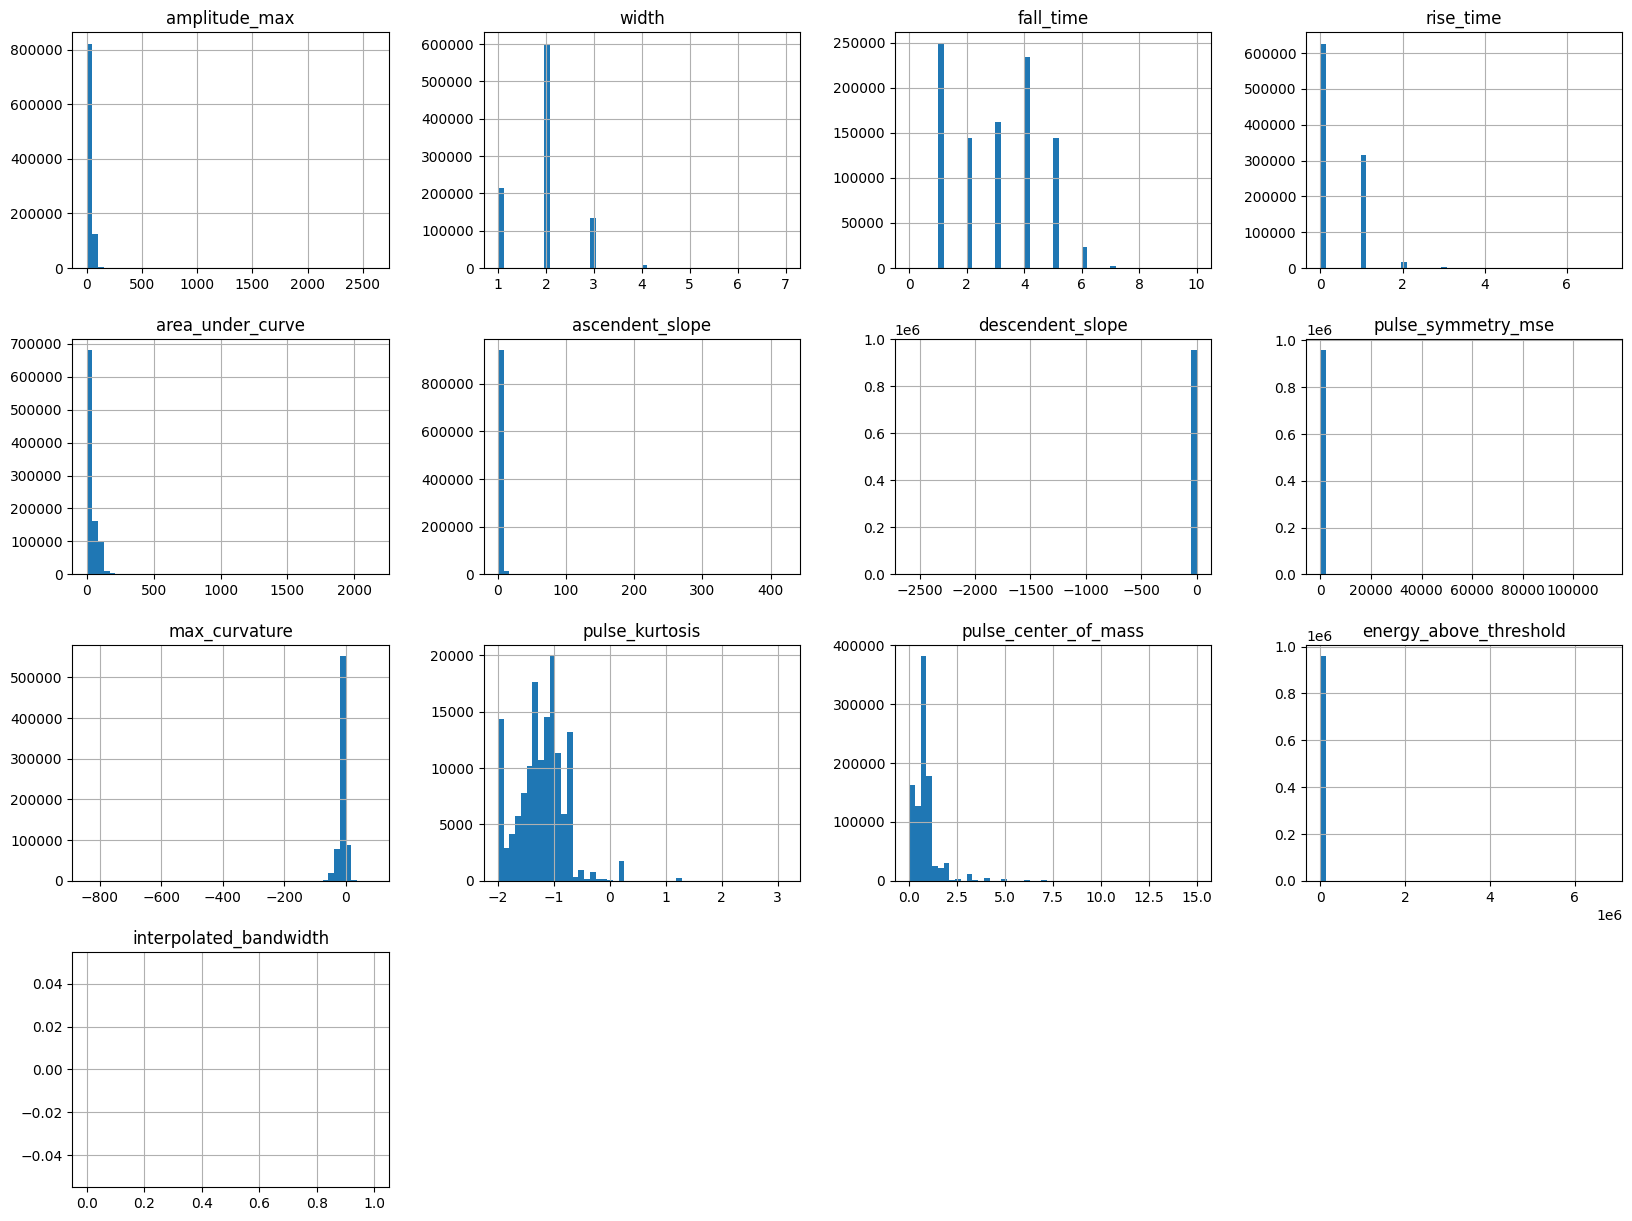

In [3]:
# histogram of each feature
import matplotlib.pyplot as plt
features.hist(bins=50, figsize=(20,15))
plt.show()

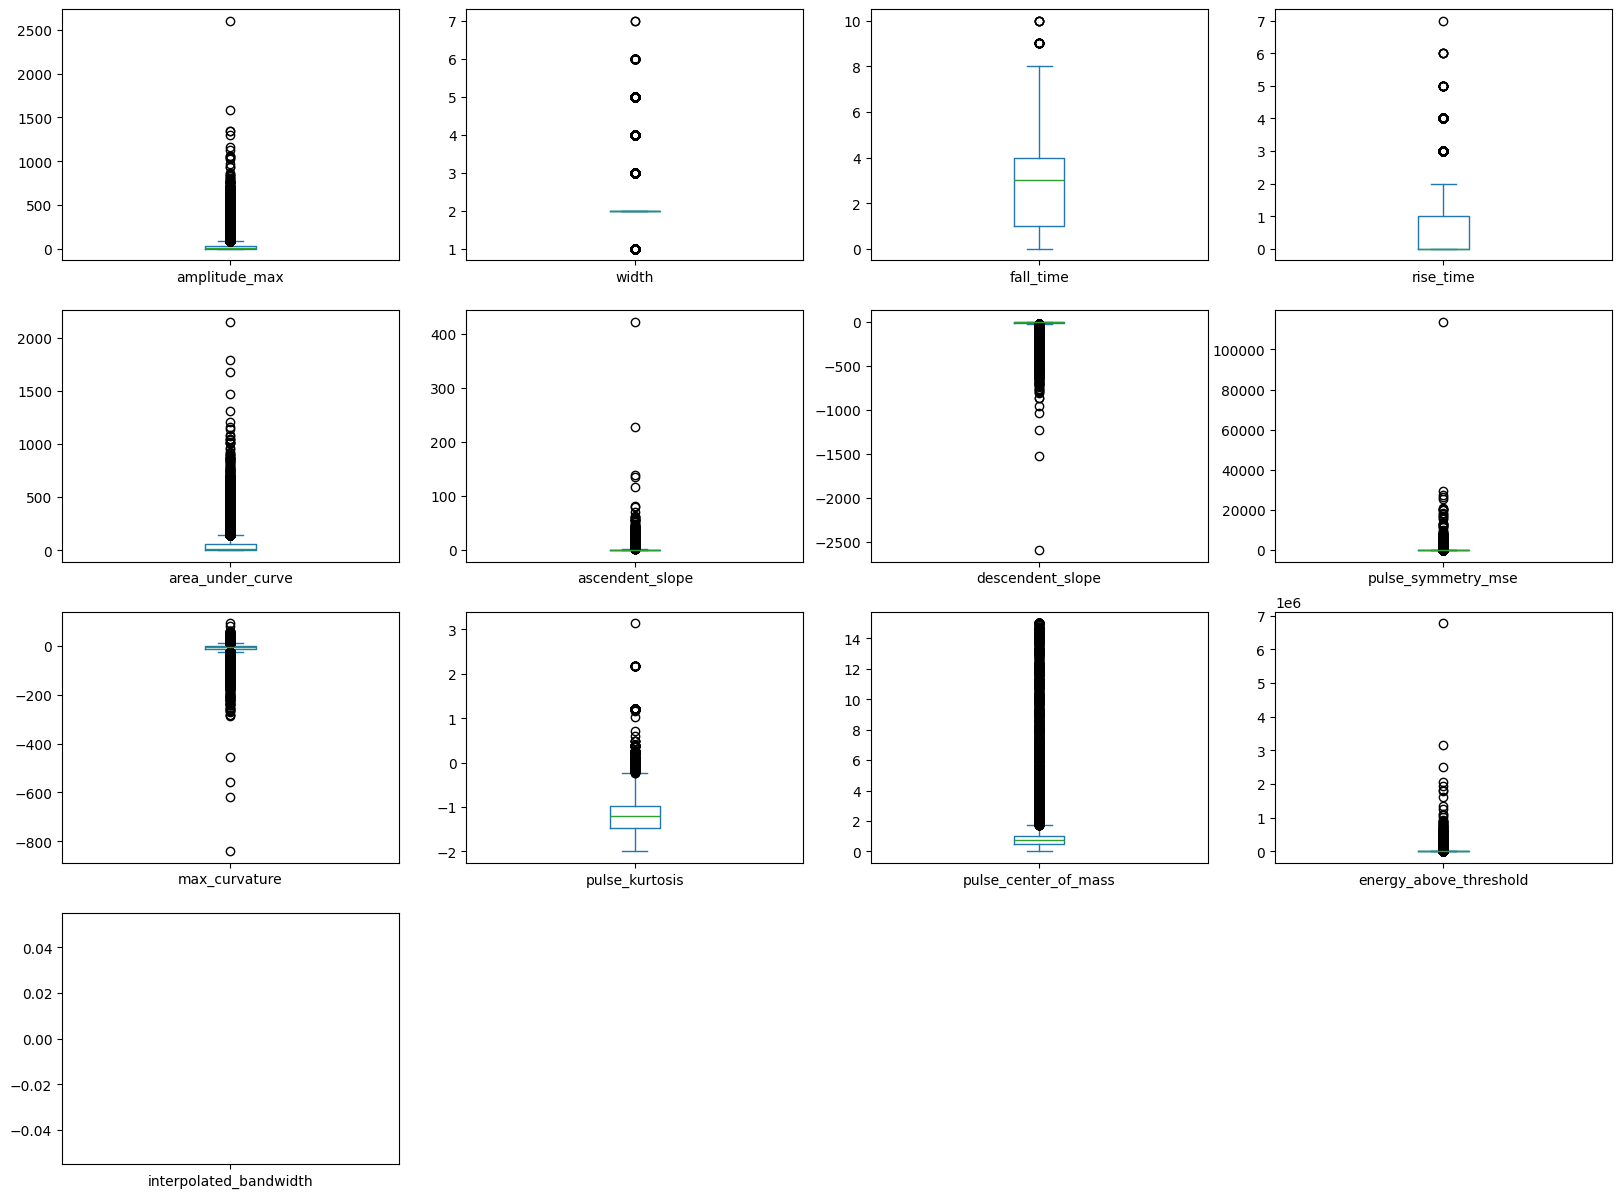

In [4]:
# boxplot of each feature
features.plot(kind='box', subplots=True, layout=(4,4), figsize=(20,15))
plt.show()


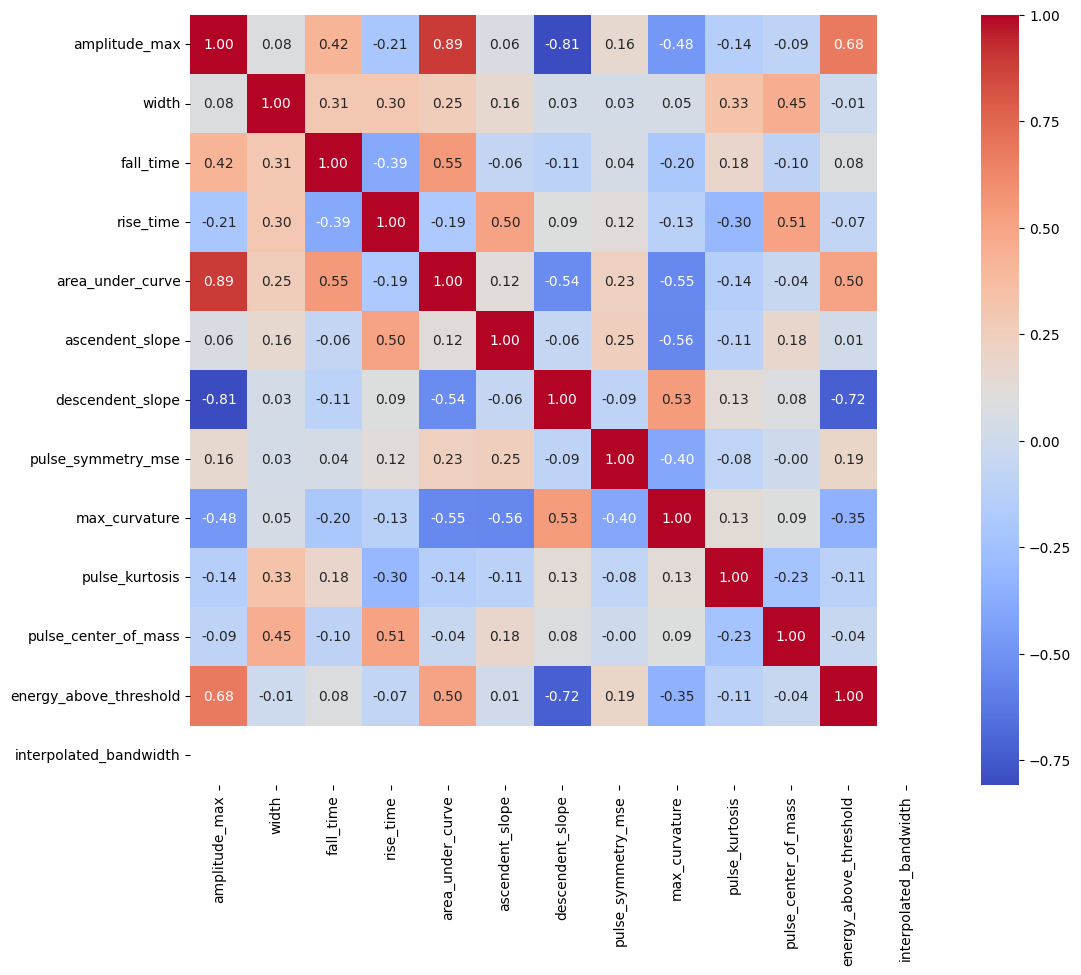

In [5]:
## correlation matrix
import seaborn as sns
corr = features.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [6]:
## print list of features by correlation with other features
for column in corr:
    sorted_corr = corr[column].abs().sort_values(ascending=False)
    print(f"Feature: {column}")
    print(sorted_corr)
    print()



Feature: amplitude_max
amplitude_max             1.000000
area_under_curve          0.892928
descendent_slope          0.808189
energy_above_threshold    0.680517
max_curvature             0.479499
fall_time                 0.419805
rise_time                 0.207013
pulse_symmetry_mse        0.163958
pulse_kurtosis            0.140154
pulse_center_of_mass      0.088156
width                     0.081857
ascendent_slope           0.061415
interpolated_bandwidth         NaN
Name: amplitude_max, dtype: float64

Feature: width
width                     1.000000
pulse_center_of_mass      0.449583
pulse_kurtosis            0.332859
fall_time                 0.306824
rise_time                 0.304002
area_under_curve          0.253841
ascendent_slope           0.163300
amplitude_max             0.081857
max_curvature             0.046073
descendent_slope          0.029039
pulse_symmetry_mse        0.028931
energy_above_threshold    0.008822
interpolated_bandwidth         NaN
Name: width, dt

In [10]:
## normalize features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_normalized = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

## show normalized features dataframe
print(features_normalized.head())

   amplitude_max     width  fall_time  rise_time  area_under_curve  \
0       0.018824  0.333333        0.4   0.000000          0.045148   
1       0.000000  0.000000        0.1   0.000000          0.000000   
2       0.000768  0.166667        0.1   0.142857          0.001629   
3       0.016519  0.166667        0.6   0.000000          0.026065   
4       0.007299  0.333333        0.3   0.000000          0.018618   

   ascendent_slope  descendent_slope  pulse_symmetry_mse  max_curvature  \
0          0.00000          0.995567            0.000000       0.903743   
1          0.00000          0.999614            0.000000            NaN   
2          0.00237          0.998843            0.000018       0.896257   
3          0.00000          0.997173            0.000000       0.905882   
4          0.00000          0.997558            0.000000       0.893048   

   pulse_kurtosis  pulse_center_of_mass  energy_above_threshold  \
0        0.136441              0.072265                0.0006

/home/agustin/Documentos/Repositorios/tesis/.venv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/agustin/Documentos/Repositorios/tesis/.venv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [7]:
## show features and labels together
labels = pd.read_csv("data/40mhz/original_labels/brc-2002_086400-01-output_true_labels.csv.gz", compression='gzip')

In [8]:
labels.iloc[:, 1:]

,class,class_detailed,0
0,eMuonic,eMuonicN,eMuonicN_n_P
1,eElectromagnetic,ePhotons,ePhotons
2,eElectromagnetic,ePhotons,ePhotons
3,eMuonic,eMuonicP,eMuonicN_n_P
4,eElectromagnetic,ePhotons,ePhotons
...,...,...,...
959437,eMuonic,eMuonicP,eMuonicN_n_P
959438,eElectromagnetic,ePhotons,ePhotons
959439,eElectromagnetic,ePositrons,eElectrons_n_ePositrons
959440,eElectromagnetic,ePhotons,ePhotons
